# 1. Problem Statement

The objective of this project is to analyze bike rental data and build a machine learning model to predict the daily bike rental count (cnt) based on environmental and seasonal factors. Accurate demand prediction helps bike-sharing companies optimize bike availability and operational planning.

# 2. Dataset Description

### 2.1 day.csv
* The day.csv dataset is the main table of this project. Each row represents one day of bike rental activity.
* It includes calendar details, weather conditions, and user rental counts.
* The target variable is cnt, which represents the total number of bikes rented per day (casual + registered).

### 2.2 hour.csv
* The hour.csv dataset records hourly bike rental activity. Each row corresponds to a specific hour of a day.
* It contains an additional column hr representing the hour and is useful for fine-grained demand analysis.

# 3. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd


## 3.1 Dataset Loading

In [3]:
day = pd.read_csv(r"C:\Bike_rental(1)\Bike_rental\day.csv")
hr  = pd.read_csv(r"C:\Bike_rental(1)\Bike_rental\hour.csv")

# 4. Initial Data Understanding

## 4.1 Shape of Dataset
* This shows the number of rows and columns in the dataset.**bold text**

In [4]:
print("bike rental by days",day.shape)
print("bike rental by hours",hr.shape)

bike rental by days (731, 16)
bike rental by hours (17379, 17)


# 4.2 Data Types and Null Values

* This output helps identify data types and missing values.


In [5]:
day.info()
day.isnull().sum().sum()


<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


np.int64(0)

# 4.3 Sample Records
* Viewing a few sample records helps us

* Understand the meaning of each column

* Verify that data is loaded correctly

* Identify potential data quality issues

In [6]:
day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [7]:
day.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [8]:
day.duplicated().sum()


np.int64(0)

# 4.3 Numerical Feature Summary

In [9]:
day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


# 5. Exploratory Data Analysis (EDA)

## 5.1 Target Variable Distribution

* Shows how bike rental demand is distributed.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns



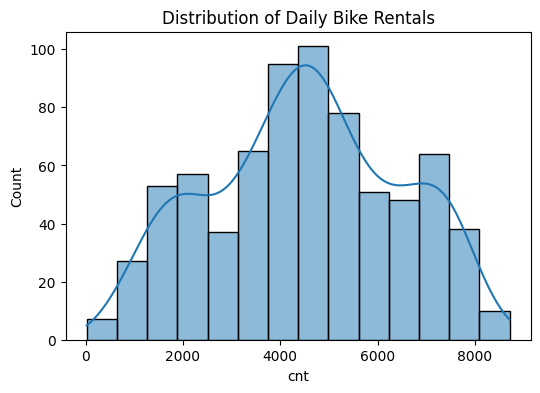

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(day['cnt'], kde=True)
plt.title("Distribution of Daily Bike Rentals")
plt.show()

## 5.2 Bike Rentals by Season

* Analyzes the effect of season on bike rentals.

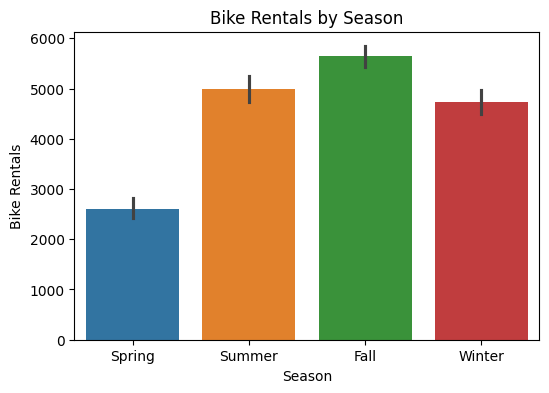

In [11]:
plt.figure(figsize=(6,4))
day['season']=day['season'].map({1:'Spring',2:'Summer',3:'Fall',4:'Winter'})
sns.barplot(x='season', y='cnt', data=day, hue='season')
plt.xlabel("Season")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals by Season")
plt.show()


# 5.3 Bike Rentals by Weather Situation
* Shows the impact of weather conditions on rentals.

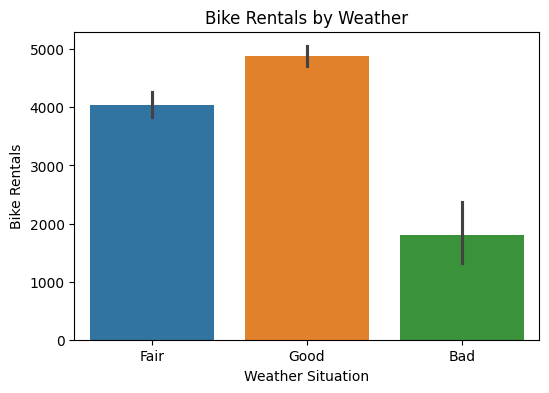

In [12]:
plt.figure(figsize=(6,4))
day['weathersit']=day['weathersit'].map({1:'Good',2:'Fair',3:'Bad'})
sns.barplot(x='weathersit', y='cnt', data=day,hue = 'weathersit')
plt.xlabel("Weather Situation")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals by Weather")
plt.show()






# 5.4 Correlation Analysis
* Displays relationships between numerical variables.

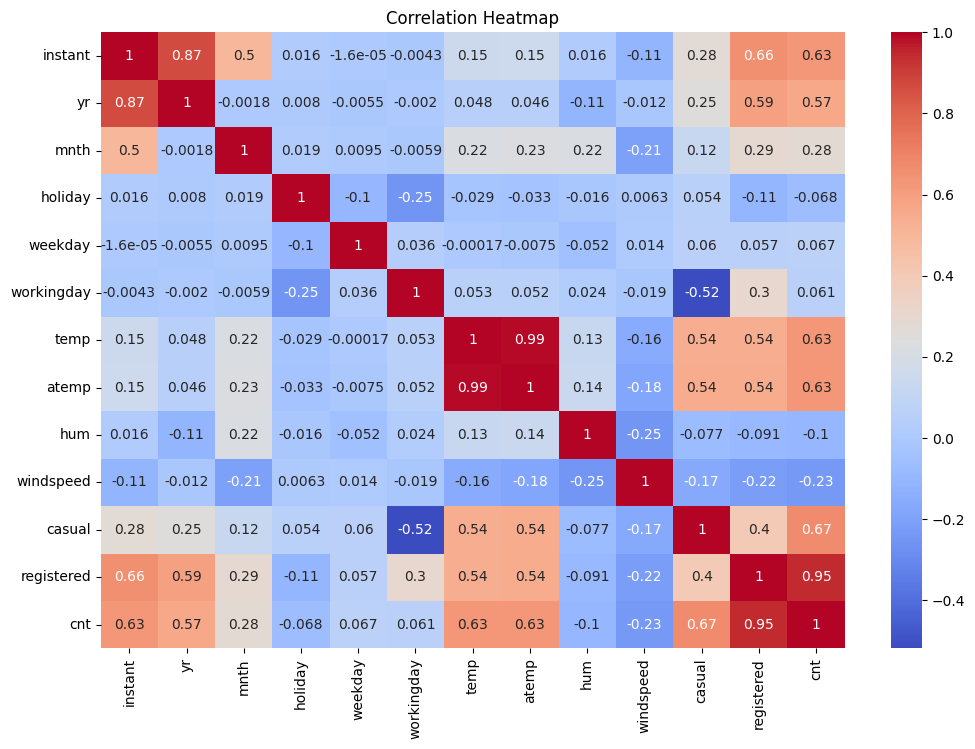

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(day.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 5.5 Bike Rentals by Month

* This visualization shows how bike rental demand varies across different months, helping identify seasonal demand trends throughout the year.


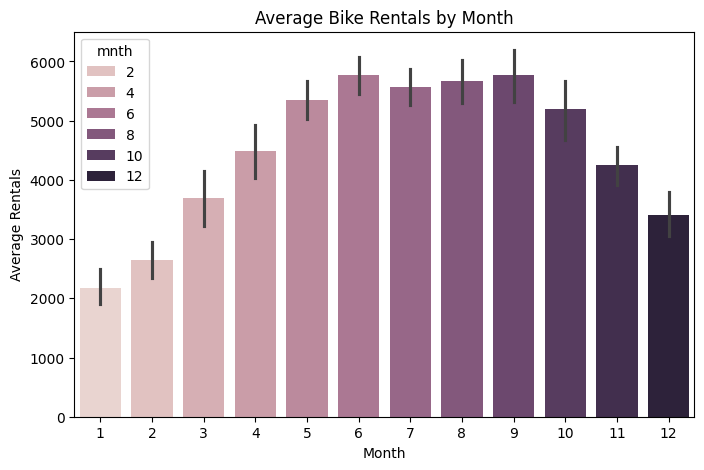

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x='mnth', y='cnt', data=day,hue = 'mnth')
plt.title("Average Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.show()


## 5.6 Bike Rentals by Weekday
* This plot compares bike rental demand across weekdays, highlighting differences between weekdays and weekends.

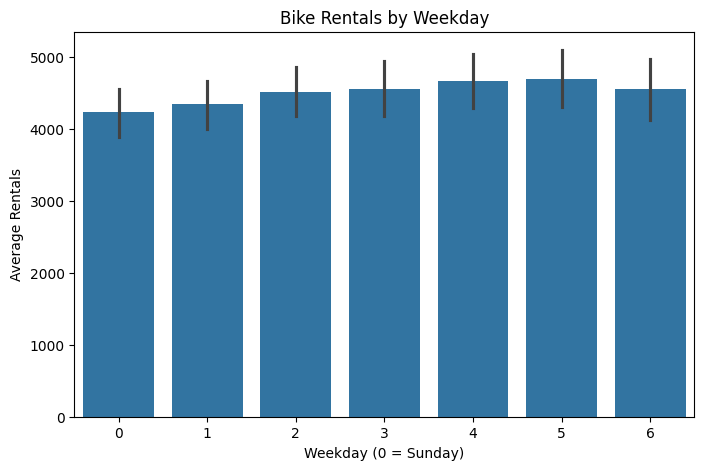

In [108]:
plt.figure(figsize=(8,5))
sns.barplot(x='weekday', y='cnt', data=day)
plt.title("Bike Rentals by Weekday")
plt.xlabel("Weekday (0 = Sunday)")
plt.ylabel("Average Rentals")
plt.show()



## 5.7 Working Day vs Non-Working Day Rentals
* This visualization compares bike rental demand on working days versus holidays or weekends.

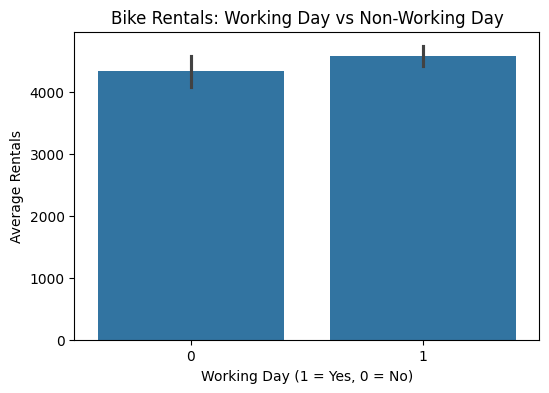

In [15]:
plt.figure(figsize=(6,4))
sns.barplot(x='workingday', y='cnt', data=day)
plt.title("Bike Rentals: Working Day vs Non-Working Day")
plt.xlabel("Working Day (1 = Yes, 0 = No)")
plt.ylabel("Average Rentals")
plt.show()


## 5.8 Temperature vs Rentals (Regression Line)
* This plot shows the relationship between temperature and bike rentals with a regression trend line.

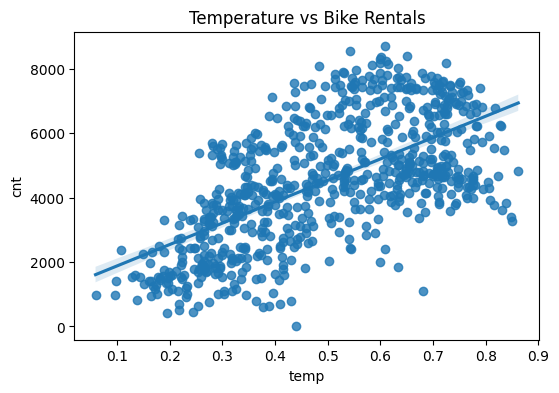

In [16]:
plt.figure(figsize=(6,4))
sns.regplot(x='temp', y='cnt', data=day)
plt.title("Temperature vs Bike Rentals")
plt.show()


##  5.9 Year-wise Bike Rental Trend
* This visualization compares bike rental demand between different years

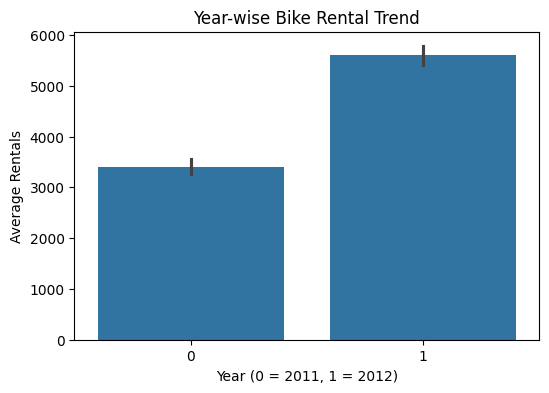

In [17]:
plt.figure(figsize=(6,4))
sns.barplot(x='yr', y='cnt', data=day)
plt.title("Year-wise Bike Rental Trend")
plt.xlabel("Year (0 = 2011, 1 = 2012)")
plt.ylabel("Average Rentals")
plt.show()


## 5.10 Pairplot of Key Numerical Features


* This plot helps visualize pairwise relationships among key numerical features and bike rental demand.

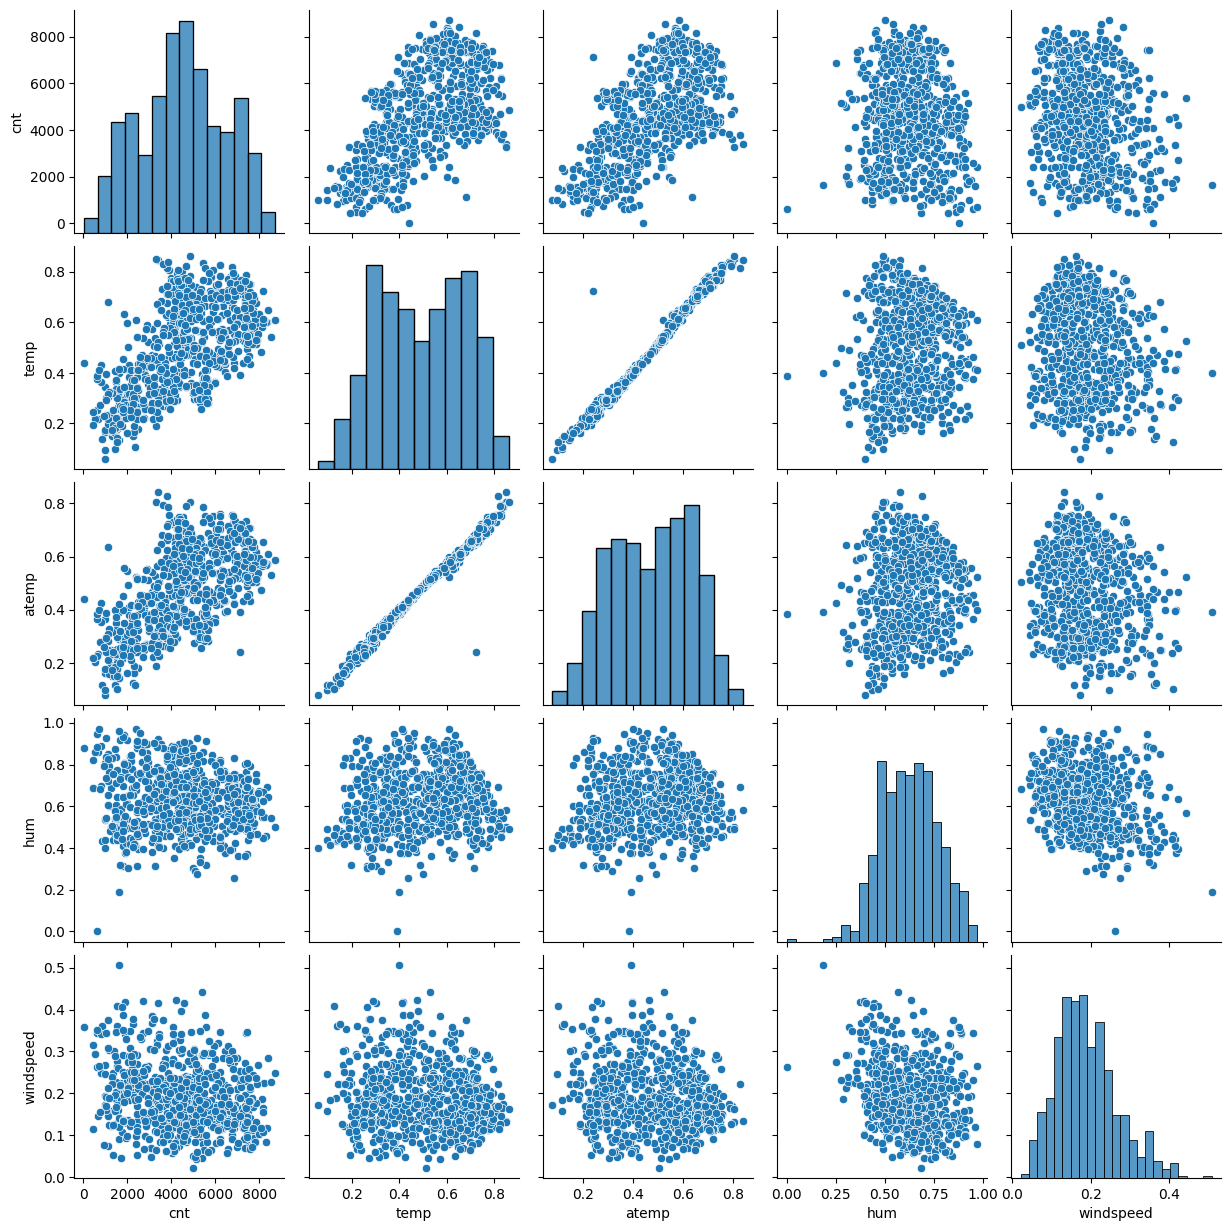

In [12]:
sns.pairplot(day[['cnt', 'temp', 'atemp', 'hum', 'windspeed']])
plt.show()


## 6. Data Cleaning

Data cleaning was not required as the dataset contained no missing values, duplicates, or data inconsistencies.

## 7. Feature Engineering

 ### 7.1 Date & Time-Based Feature Engineering

* Temporal features help capture daily, weekly, and monthly rental trends.

In [13]:
# Convert date to datetime
day['dteday'] = pd.to_datetime(day['dteday'])

# Extract time-based features
day['day'] = day['dteday'].dt.day
day['month'] = day['dteday'].dt.month
day['day_of_week'] = day['dteday'].dt.weekday
day['is_weekend'] = day['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


###  7.2 Season Grouping Feature

Grouping seasons simplifies the model’s understanding of seasonal demand patterns.

In [14]:
season_map = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Fall'
}

day['season_name'] = day['season'].map(season_map)


### 7.3 Weather Severity Feature

Weather severity groups similar weather conditions into broader categories.

In [15]:
weather_map = {
    1: 'Good',
    2: 'Moderate',
    3: 'Bad',
    4: 'Very Bad'
}

day['weather_severity'] = day['weathersit'].map(weather_map)


### 7.4 Temperature Comfort Index

This feature captures the perceived comfort level by combining temperature and humidity.

In [16]:
day['temp_comfort'] = day['temp'] * (1 - day['hum'])


### 7.5 User Behavior Ratio Features

These ratios show dependency on casual vs registered users.

In [17]:
day['casual_ratio'] = day['casual'] / (day['cnt'] + 1)
day['registered_ratio'] = day['registered'] / (day['cnt'] + 1)


### 7.6 Working Day & Season Interaction

Captures different rental behavior on working days across seasons.

In [18]:
day['season_workingday'] = day['season'] * day['workingday']


### 7.7 Drop Redundant Columns

Remove columns not useful for prediction or causing leakage.

In [19]:
day= day.drop(['instant', 'dteday'], axis=1)


 ### 7.8 Encode Categorical Features

Convert categorical variables into numerical form.

In [20]:
day = pd.get_dummies(day, drop_first=True)
day

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,...,is_weekend,temp_comfort,casual_ratio,registered_ratio,season_workingday,season_name_Spring,season_name_Summer,season_name_Winter,weather_severity_Good,weather_severity_Moderate
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,...,1,0.066826,0.335700,0.663286,0,False,False,True,False,True
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,...,1,0.110466,0.163342,0.835411,0,False,False,True,False,True
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,...,0,0.110499,0.088889,0.910370,1,False,False,True,True,False
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,...,0,0.081913,0.069098,0.930262,1,False,False,True,True,False
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,...,0,0.127787,0.051218,0.948157,1,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,...,0,0.088217,0.116785,0.882742,1,False,False,True,False,True
727,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,...,0,0.103867,0.208010,0.791667,1,False,False,True,False,True
728,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,...,1,0.062594,0.118480,0.880775,0,False,False,True,False,True
729,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,...,1,0.132180,0.202560,0.796884,0,False,False,True,True,False


### 7.9 Final Feature Set

Separate features and target variable for modeling.

In [21]:
X = day.drop('cnt', axis=1)
y = day['cnt']

print("Final feature shape:", X.shape)


Final feature shape: (731, 26)


## 9. Train-Test Split

Splits data into training and testing sets.

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### 10. Feature Scaling

Scaling ensures all features contribute equally.

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test= min_max_scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append([
        name,
        mean_absolute_error(y_test, preds),
        np.sqrt(mean_squared_error(y_test, preds)),
        r2_score(y_test, preds)
    ])


In [28]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.849925e-12,2.772755e-12,1.000000
1,Decision Tree,1.464354e+02,2.039554e+02,0.989626
2,Random Forest,6.967503e+01,1.114441e+02,0.996903
3,Gradient Boosting,7.271017e+01,1.006193e+02,0.997475


In [29]:
results_df.sort_values(by="R2 Score", ascending=False)


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.849925e-12,2.772755e-12,1.000000
3,Gradient Boosting,7.271017e+01,1.006193e+02,0.997475
2,Random Forest,6.967503e+01,1.114441e+02,0.996903
1,Decision Tree,1.464354e+02,2.039554e+02,0.989626


In [30]:
from sklearn.metrics import accuracy_score

In [31]:
train_accuracy = model.score(X_train, y_train)
print("Test Accuracy:", train_accuracy * 100)

Test Accuracy: 99.89978687639467


In [32]:
test_accuracy = model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy * 100)

Test Accuracy: 99.74751745776935


In [33]:
final_model =  GradientBoostingRegressor(random_state=42)
final_model.fit(X_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [34]:
final_preds = final_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, final_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, final_preds)))
print("R2 Score:", r2_score(y_test, final_preds))


MAE: 72.71017448633542
RMSE: 100.6193457674631
R2 Score: 0.9974751745776934


In [35]:
importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance


registered                   8.631075e-01
casual                       1.298351e-01
registered_ratio             6.418410e-03
casual_ratio                 2.272338e-04
windspeed                    1.010424e-04
hum                          5.886569e-05
month                        5.162647e-05
atemp                        4.656137e-05
mnth                         3.721258e-05
temp_comfort                 3.317527e-05
temp                         2.913621e-05
weekday                      2.014701e-05
day                          1.316611e-05
season_workingday            8.580745e-06
day_of_week                  8.290979e-06
yr                           2.880617e-06
weather_severity_Good        9.382059e-07
weathersit                   6.976709e-08
season                       4.617899e-08
season_name_Summer           1.385333e-08
holiday                      0.000000e+00
workingday                   0.000000e+00
is_weekend                   0.000000e+00
season_name_Spring           0.000

In [36]:
input_data = (
    '2012-02-15', # dteday (placeholder based on yr, mnth)
    4,            # season (corrected from 2 to 4 based on original mapping: 1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter')
    1,            # yr (corrected from 2 to 1 for 2012, as only 0 and 1 exist)
    2,            # mnth
    0,            # holiday
    3,            # weekday
    1,            # workingday
    1,            # weathersit
    0.30,         # temp
    0.30,         # atemp
    0.55,         # hum
    0.20,         # windspeed
    100,          # casual (placeholder)
    1000,         # registered (placeholder)
    1100          # cnt (placeholder: casual + registered)
)

raw_columns = [
    "dteday", "season","yr","mnth","holiday","weekday",
    "workingday","weathersit","temp","atemp","hum","windspeed",
    "casual", "registered", "cnt"
]

input_df_raw = pd.DataFrame([input_data], columns=raw_columns)

In [37]:
# Re-initialize sample_input with the new raw input data
sample_input = input_df_raw.copy()

print("New sample_input initialized from input_df_raw:")
print(sample_input.head())

New sample_input initialized from input_df_raw:
       dteday  season  yr  mnth  holiday  weekday  workingday  weathersit  \
0  2012-02-15       4   1     2        0        3           1           1   

   temp  atemp   hum  windspeed  casual  registered   cnt  
0   0.3    0.3  0.55        0.2     100        1000  1100  


In [38]:
sample_input['dteday'] = pd.to_datetime(sample_input['dteday'])
sample_input['day'] = sample_input['dteday'].dt.day
sample_input['month'] = sample_input['dteday'].dt.month
sample_input['day_of_week'] = sample_input['dteday'].dt.weekday
sample_input['is_weekend'] = sample_input['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

season_map = {
    1: 'Winter',
    2: 'Spring',
    3: 'Fall',
    4: 'Summer'
}
sample_input['season_name'] = sample_input['season'].map(season_map)

weather_map = {
    1: 'Good',
    2: 'Moderate',
    3: 'Bad',
    4: 'Very Bad'
}
sample_input['weather_severity'] = sample_input['weathersit'].map(weather_map)

sample_input['temp_comfort'] = sample_input['temp'] * (1 - sample_input['hum'])
sample_input['casual_ratio'] = sample_input['casual'] / (sample_input['cnt'] + 1)
sample_input['registered_ratio'] = sample_input['registered'] / (sample_input['cnt'] + 1)

sample_input['season_workingday'] = sample_input['season'] * sample_input['workingday']

print("Sample input after feature engineering (first 5 columns): ")
print(sample_input.iloc[:, :5])

Sample input after feature engineering (first 5 columns): 
      dteday  season  yr  mnth  holiday
0 2012-02-15       4   1     2        0


In [39]:
sample_input = sample_input.drop(['instant', 'dteday'], axis=1, errors='ignore') # Added errors='ignore' in case instant is already dropped
print("Sample input after dropping redundant columns:")
print(sample_input.head())

Sample input after dropping redundant columns:
   season  yr  mnth  holiday  weekday  workingday  weathersit  temp  atemp  \
0       4   1     2        0        3           1           1   0.3    0.3   

    hum  ...  day  month  day_of_week  is_weekend  season_name  \
0  0.55  ...   15      2            2           0       Summer   

   weather_severity  temp_comfort  casual_ratio registered_ratio  \
0              Good         0.135      0.090827         0.908265   

  season_workingday  
0                 4  

[1 rows x 24 columns]


In [40]:
sample_input = sample_input.drop('cnt', axis=1)

# Re-apply the explicit mappings from EDA that seemed to influence the final X columns
season_categorical_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weathersit_categorical_map = {1:'Good', 2:'Fair', 3:'Bad'}

sample_input['season'] = sample_input['season'].map(season_categorical_map)
sample_input['weathersit'] = sample_input['weathersit'].map(weathersit_categorical_map)

# Drop the 'season_name' and 'weather_severity' columns created earlier,
# as the final model's dummy variables seem to come from the re-mapped 'season' and 'weathersit' directly.
# Also drop 'season_name' and 'weather_severity' if they exist, to prevent redundant dummy variables
if 'season_name' in sample_input.columns:
    sample_input = sample_input.drop('season_name', axis=1)
if 'weather_severity' in sample_input.columns:
    sample_input = sample_input.drop('weather_severity', axis=1)

print("Sample input after dropping target and re-mapping categoricals:")
print(sample_input.head())

Sample input after dropping target and re-mapping categoricals:
   season  yr  mnth  holiday  weekday  workingday weathersit  temp  atemp  \
0  Winter   1     2        0        3           1       Good   0.3    0.3   

    hum  ...  casual  registered  day  month  day_of_week  is_weekend  \
0  0.55  ...     100        1000   15      2            2           0   

   temp_comfort  casual_ratio  registered_ratio  season_workingday  
0         0.135      0.090827          0.908265                  4  

[1 rows x 21 columns]


In [41]:
sample_input = pd.get_dummies(sample_input, drop_first=True)

# Align columns with the training data's features (X)
# This is crucial to ensure the prediction input has the exact same columns and order as the training data
missing_cols = set(X.columns) - set(sample_input.columns)
for c in missing_cols:
    sample_input[c] = 0
sample_input = sample_input[X.columns]

print("Sample input after final one-hot encoding and column alignment:")
print(sample_input.head())
print("Shape of sample_input after alignment:", sample_input.shape)

Sample input after final one-hot encoding and column alignment:
   season  yr  mnth  holiday  weekday  workingday  weathersit  temp  atemp  \
0       0   1     2        0        3           1           0   0.3    0.3   

    hum  ...  is_weekend  temp_comfort  casual_ratio  registered_ratio  \
0  0.55  ...           0         0.135      0.090827          0.908265   

   season_workingday  season_name_Spring  season_name_Summer  \
0                  4                   0                   0   

   season_name_Winter  weather_severity_Good  weather_severity_Moderate  
0                   0                      0                          0  

[1 rows x 26 columns]
Shape of sample_input after alignment: (1, 26)


In [42]:
sample_input_scaled = min_max_scaler.transform(sample_input)
print("Sample input after scaling:")
print(sample_input_scaled)
print("Shape of sample_input after scaling:", sample_input_scaled.shape)

Sample input after scaling:
[[-0.33333333  1.          0.09090909  0.          0.5         1.
  -0.5         0.30013535  0.29000098  0.57142857  0.42371293  0.02675684
   0.08943338  0.46666667  0.09090909  0.33333333  0.          0.24802616
   0.15625519  0.84446466  1.          0.          0.          0.
   0.          0.        ]]
Shape of sample_input after scaling: (1, 26)


In [43]:
predicted_cnt = final_model.predict(sample_input_scaled)
print("Predicted Bike Rental Count for sample input:", predicted_cnt[0])

Predicted Bike Rental Count for sample input: 1075.186376375678


In [44]:
import pickle
filename='Bike rental.sav'
pickle.dump(final_model, open(filename,"wb"))
loaded_model=pickle.load(open(filename,"rb"))

In [45]:
prediction = loaded_model.predict(sample_input_scaled)

print("Predicted Bike Rentals:", int(prediction[0]))

Predicted Bike Rentals: 1075


In [46]:
pred_value = int(prediction[0])

if pred_value < 2000:
    print("🚲 Low rental demand expected")
elif pred_value < 4000:
    print("🚲 Moderate rental demand expected")
else:
    print("🚲 High rental demand expected")

🚲 Low rental demand expected


In [47]:
import pickle

scaler_filename = 'min_max_scaler.sav'
pickle.dump(min_max_scaler, open(scaler_filename, 'wb'))
print(f"MinMaxScaler saved to {scaler_filename}")

MinMaxScaler saved to min_max_scaler.sav


In [48]:
import pickle

scaler_filename = 'min_max_scaler.sav'
loaded_scaler = pickle.load(open(scaler_filename, 'rb'))
print(f"MinMaxScaler loaded from {scaler_filename}")



MinMaxScaler loaded from min_max_scaler.sav
